In [1]:
# ─────────────────────────────────────────────
# IMPORTS & SETUP
# ─────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature

BASE_FILE = Path.cwd() / "../glofas5_hydrobot.csv"
DIR_OUT   = Path.cwd() / "../results"

df = pd.read_csv(BASE_FILE).reset_index(drop=True)
print(f"Stations: {len(df)}")
print(f"Columns: {len(df.columns)}")

Stations: 5379
Columns: 91


## Methods

In [2]:
# ─────────────────────────────────────────────
# BUDYKO FRAMEWORK
# Axes:
#   x = Aridity Index  = PET/P  (dryness ratio)
#   y = Evaporative Index = ET/P (evaporation ratio)
#
# Theoretical curves:
#   Budyko (1974):     ET/P = [AI * tanh(1/AI) * (1 - exp(-AI))]^0.5
#   Turc-Pike:         ET/P = 1 / sqrt(1 + (1/AI)^2)
#   Schreiber (1904):  ET/P = 1 - exp(-AI)
# ─────────────────────────────────────────────

# ── Compute Evaporative Index ──
df["evaporative_index"] = df["eta_mean_annual"] / df["tp_mean_annual"]

# Sanity checks
print(f"EI > 1 (unrealistic — ET > P): {(df['evaporative_index'] > 1).sum()} stations")
print(f"EI < 0 (unrealistic):          {(df['evaporative_index'] < 0).sum()} stations")
print(df["evaporative_index"].describe().round(3))

# ── Theoretical Budyko curves ──
ai_line = np.linspace(0.01, 15, 500)

# Budyko (1974) original
budyko_curve = np.sqrt(
    ai_line * np.tanh(1 / ai_line) * (1 - np.exp(-ai_line))
)

# Turc-Pike
turc_pike = 1 / np.sqrt(1 + (1 / ai_line) ** 2)

# Schreiber
schreiber = 1 - np.exp(-ai_line)

# Physical limits
limit_energy = np.minimum(ai_line, 1.0)   # ET/P ≤ PET/P (energy limit)
limit_water  = np.ones_like(ai_line)       # ET/P ≤ 1 (water limit)

# ── Budyko Deviation (from Turc-Pike as reference) ──
df["budyko_expected"] = 1 / np.sqrt(1 + (1 / df["aridity_index"]) ** 2)
df["budyko_deviation"] = df["evaporative_index"] - df["budyko_expected"]

print(f"\nBudyko Deviation:")
print(df["budyko_deviation"].describe().round(3))
print(f"\nStations above Budyko curve (ET > expected): {(df['budyko_deviation'] > 0).sum()}")
print(f"Stations below Budyko curve (ET < expected): {(df['budyko_deviation'] < 0).sum()}")

EI > 1 (unrealistic — ET > P): 5 stations
EI < 0 (unrealistic):          0 stations
count    5262.000
mean        0.539
std         0.150
min         0.025
25%         0.434
50%         0.534
75%         0.636
max         1.189
Name: evaporative_index, dtype: float64

Budyko Deviation:
count    5262.000
mean       -0.136
std         0.101
min        -0.873
25%        -0.184
50%        -0.111
75%        -0.070
max         0.226
Name: budyko_deviation, dtype: float64

Stations above Budyko curve (ET > expected): 121
Stations below Budyko curve (ET < expected): 5141


In [29]:
# ─────────────────────────────────────────────
# LISA RECOMPUTATION (from Notebook 03)
# Method: Local Moran's I (LISA)
#   Weights: k-Nearest Neighbours (k=10), row-standardised
#   Permutations: 999 (local null distribution per station)
#   Significance threshold: p < 0.05
#
# Quadrant classification:
#   HH: above-average KGE, above-average neighbourhood
#   LL: below-average KGE, below-average neighbourhood
#   HL: above-average KGE, below-average neighbourhood
#   LH: below-average KGE, above-average neighbourhood
#   ns: not significant
# ─────────────────────────────────────────────
from libpysal.weights import KNN, lag_spatial
from esda.moran import Moran_Local

df_lisa = df[["ID", "lon", "lat", "KGEmod"]].dropna().reset_index(drop=True)
coords  = df_lisa[["lon", "lat"]].values
w       = KNN.from_array(coords, k=10)
w.transform = "r"
lisa    = Moran_Local(df_lisa["KGEmod"].values, w, permutations=999)

quad_labels = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
df_lisa["lisa_label"] = [quad_labels[q] for q in lisa.q]
df_lisa.loc[lisa.p_sim >= 0.05, "lisa_label"] = "ns"

df = df.merge(df_lisa[["ID", "lisa_label"]], on="ID", how="left")
print(df["lisa_label"].value_counts())

/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


lisa_label
ns    2944
HH    1412
LL     760
LH     136
HL     127
Name: count, dtype: int64


## Analysis

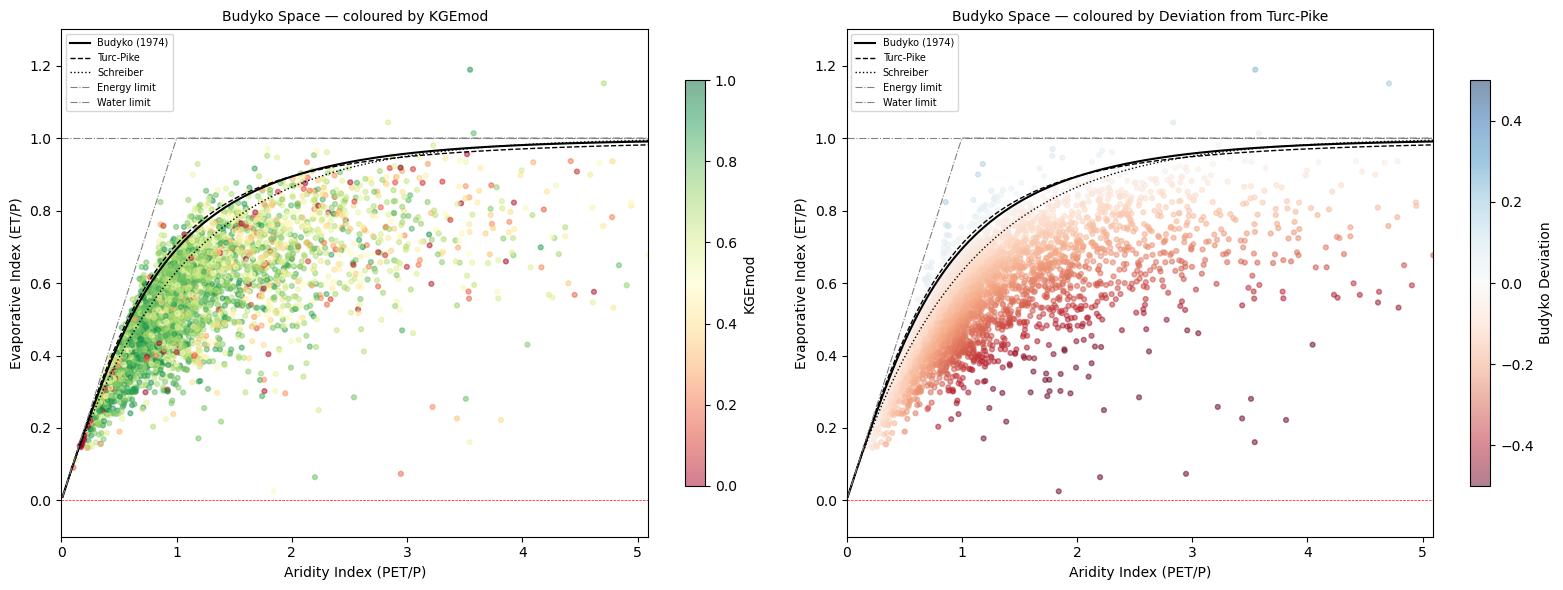

In [19]:
# ─────────────────────────────────────────────
# PLOT 1: Budyko Space — eingefärbt nach KGE
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cvar, clabel, vmin, vmax, cmap, title_suffix in [
    (axes[0], "KGEmod",          "KGEmod",        0,    1,   "RdYlGn",  "coloured by KGEmod"),
    (axes[1], "budyko_deviation", "Budyko Deviation", -0.5, 0.5, "RdBu",  "coloured by Deviation from Turc-Pike"),
]:
    valid = df[["aridity_index", "evaporative_index", cvar]].dropna().reset_index(drop=True)

    # clip x-axis
    x_clip = valid["aridity_index"].quantile(0.99)
    plot_data = valid[valid["aridity_index"] <= x_clip]

    # theoretical curves
    ax.plot(ai_line, budyko_curve, "k-",  linewidth=1.5, label="Budyko (1974)")
    ax.plot(ai_line, turc_pike,    "k--", linewidth=1.0, label="Turc-Pike")
    ax.plot(ai_line, schreiber,    "k:",  linewidth=1.0, label="Schreiber")
    ax.plot(ai_line, limit_energy, "gray", linewidth=0.8, linestyle="-.", label="Energy limit")
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="-.", label="Water limit")

    sc = ax.scatter(plot_data["aridity_index"],
                    plot_data["evaporative_index"],
                    c=plot_data[cvar], cmap=cmap,
                    alpha=0.5, s=12, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, label=clabel, shrink=0.8)

    ax.set_xlim(0, x_clip)
    ax.set_ylim(-0.1, 1.3)
    ax.set_xlabel("Aridity Index (PET/P)", fontsize=10)
    ax.set_ylabel("Evaporative Index (ET/P)", fontsize=10)
    ax.set_title(f"Budyko Space — {title_suffix}", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
    ax.axhline(0, color="red", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(DIR_OUT / "budyko_space.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
# Check Verteilung zuerst
print(df["budyko_deviation"].describe())
print(df["budyko_deviation"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

count    5262.000000
mean       -0.136486
std         0.100618
min        -0.873320
25%        -0.183559
50%        -0.111151
75%        -0.069760
max         0.226118
Name: budyko_deviation, dtype: float64
0.10   -0.275843
0.25   -0.183559
0.50   -0.111151
0.75   -0.069760
0.90   -0.039598
Name: budyko_deviation, dtype: float64


/tmp/ipykernel_549494/490134968.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=dev_labels, patch_artist=True, notch=False, widths=0.4,


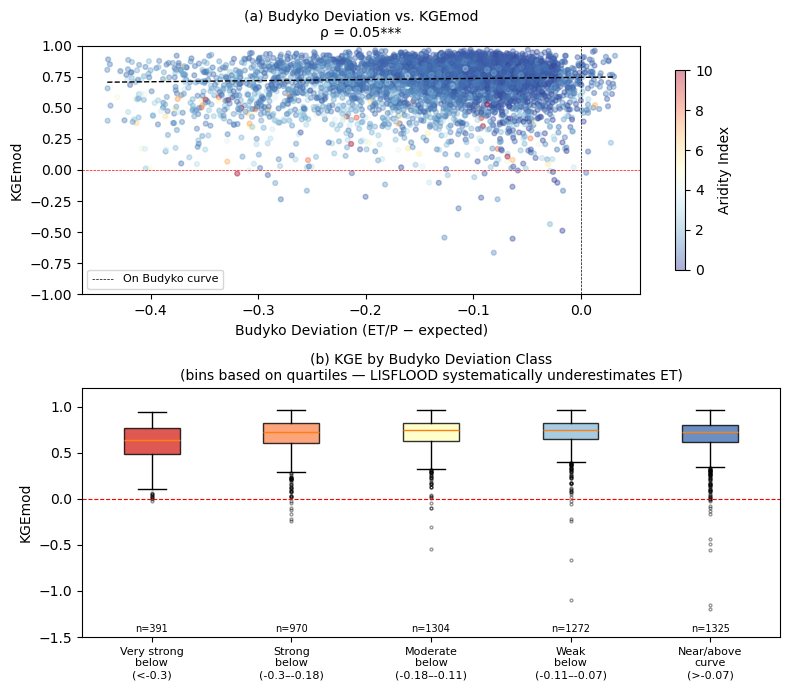

In [22]:
# ─────────────────────────────────────────────
# PLOT 2: Budyko Deviation vs KGE
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# ── Oben: Scatter Deviation vs KGE ──
ax = axes[0]
valid = df[["budyko_deviation", "KGEmod", "aridity_index"]].dropna().reset_index(drop=True)

# x-Achse auf sinnvollen Bereich clippen
x_low  = valid["budyko_deviation"].quantile(0.01)
x_high = valid["budyko_deviation"].quantile(0.99)
plot_data = valid[(valid["budyko_deviation"] >= x_low) &
                  (valid["budyko_deviation"] <= x_high)]

sc = ax.scatter(plot_data["budyko_deviation"], plot_data["KGEmod"],
                c=plot_data["aridity_index"], cmap="RdYlBu_r",
                alpha=0.4, s=12, vmin=0, vmax=10)
plt.colorbar(sc, ax=ax, label="Aridity Index", shrink=0.8)
res = stats.theilslopes(plot_data["KGEmod"], plot_data["budyko_deviation"])
x_line = np.linspace(plot_data["budyko_deviation"].min(),
                     plot_data["budyko_deviation"].max(), 100)
ax.plot(x_line, res.slope * x_line + res.intercept, "k--", linewidth=1)
ax.axhline(0, color="red",   linestyle="--", linewidth=0.5)
ax.axvline(0, color="black", linestyle="--", linewidth=0.5, label="On Budyko curve")
rho, pval = stats.spearmanr(valid["budyko_deviation"], valid["KGEmod"])
pstar = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
ax.set_xlabel("Budyko Deviation (ET/P − expected)", fontsize=10)
ax.set_ylabel("KGEmod", fontsize=10)
ax.set_title(f"(a) Budyko Deviation vs. KGEmod\nρ = {rho:.2f}{pstar}", fontsize=10)
ax.set_ylim(-1, 1)
ax.legend(fontsize=8)

# ── Unten: Boxplot — Bins basierend auf Quantilen ──
ax = axes[1]

# Bins basierend auf tatsächlicher Verteilung
# Mean=-0.14, fast alle negativ, max=0.23
dev_bins   = [-1, -0.3, -0.18, -0.11, -0.07, 0.25]
dev_labels = ["Very strong\nbelow\n(<-0.3)",
              "Strong\nbelow\n(-0.3–-0.18)",
              "Moderate\nbelow\n(-0.18–-0.11)",
              "Weak\nbelow\n(-0.11–-0.07)",
              "Near/above\ncurve\n(>-0.07)"]

df["budyko_class"] = pd.cut(df["budyko_deviation"],
                             bins=dev_bins, labels=dev_labels)
data_by_class = [df[df.budyko_class == c]["KGEmod"].dropna().values
                 for c in dev_labels]
bp = ax.boxplot(data_by_class, labels=dev_labels, patch_artist=True, notch=False, widths=0.4,
                flierprops=dict(marker="o", markersize=2, alpha=0.4, linestyle="none"))

colors_box = ["#d73027", "#fc8d59", "#ffffbf", "#91bfdb", "#4575b4"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_ylabel("KGEmod", fontsize=10)
ax.set_title("(b) KGE by Budyko Deviation Class\n"
             "(bins based on quartiles — LISFLOOD systematically underestimates ET)",
             fontsize=10)
ax.set_ylim(-1.5, 1.2)
ax.set_xticklabels(dev_labels, fontsize=8)

# N nach ylim
for i, (cls, d) in enumerate(zip(dev_labels, data_by_class)):
    ax.text(i + 1, -1.45, f"n={len(d)}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig(DIR_OUT / "budyko_deviation_vs_kge.png", dpi=200, bbox_inches="tight")


/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


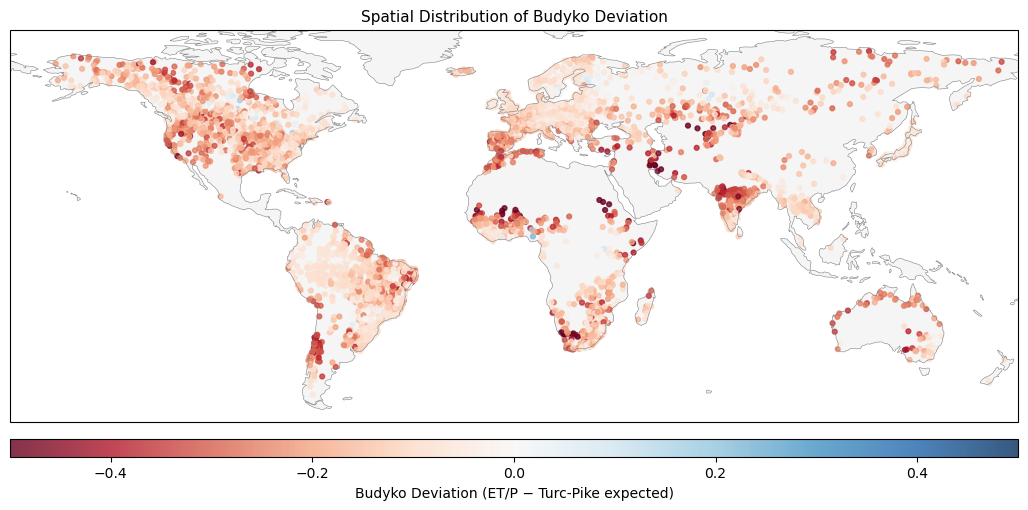

In [51]:
# ─────────────────────────────────────────────
# PLOT 3: Räumliche Karte der Budyko Deviation
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_axes([0.02, 0.1, 0.72, 0.85], projection=ccrs.PlateCarree())
cax = fig.add_axes([0.02, 0.14, 0.72, 0.03])

ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color="gray")
ax.add_feature(cfeature.LAND,      facecolor="whitesmoke")
# ax.add_feature(cfeature.OCEAN,     facecolor="aliceblue")

valid = df[["lon", "lat", "budyko_deviation"]].dropna()
sc = ax.scatter(valid["lon"], valid["lat"],
                c=valid["budyko_deviation"],
                cmap="RdBu", s=12, vmin=-0.5, vmax=0.5,
                alpha=0.8, transform=ccrs.PlateCarree())
plt.colorbar(sc, cax=cax, orientation="horizontal",
             label="Budyko Deviation (ET/P − Turc-Pike expected)")
ax.set_title("Spatial Distribution of Budyko Deviation", fontsize=11)

plt.savefig(DIR_OUT / "budyko_deviation_map.png", dpi=200, bbox_inches="tight")
plt.show()

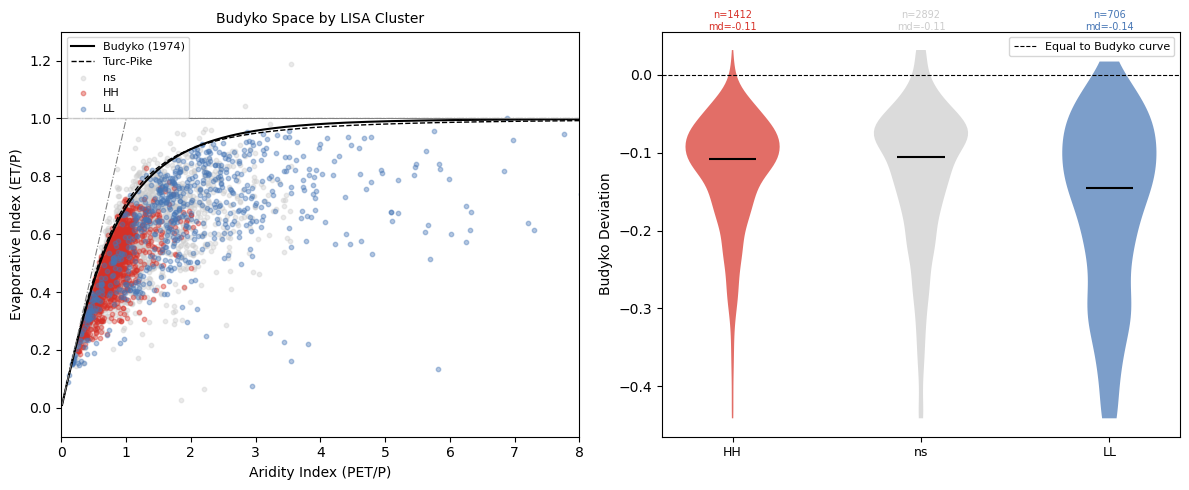

In [38]:
# ─────────────────────────────────────────────
# PLOT 4: Budyko Deviation — HH vs LL Cluster
# Verbindung zur Moran's I Analyse aus 03
# ─────────────────────────────────────────────

# LISA Labels aus 03 laden falls verfügbar
# → falls nicht: lisa_label Spalte manuell hinzufügen
if "lisa_label" not in df.columns:
    print("lisa_label nicht in df — bitte aus 03 mergen:")
    print("df = df.merge(lisa_df[['ID','lisa_label']], on='ID', how='left')")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ── Links: Budyko Space HH vs LL ──
    ax = axes[0]
    ax.plot(ai_line, budyko_curve, "k-",  linewidth=1.5, label="Budyko (1974)")
    ax.plot(ai_line, turc_pike,    "k--", linewidth=1.0, label="Turc-Pike")
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="-.")
    ax.plot(ai_line, limit_energy, color="gray", linewidth=0.8, linestyle="-.")

    cluster_colors = {"ns": "#cccccc", "HH": "#d73027", "LL": "#4575b4"}
    for label, color in cluster_colors.items():
        sub = df[(df["lisa_label"] == label)][
            ["aridity_index", "evaporative_index"]].dropna()
        x_clip = sub["aridity_index"].quantile(0.99)
        sub = sub[sub["aridity_index"] <= x_clip]
        ax.scatter(sub["aridity_index"], sub["evaporative_index"],
                   c=color, alpha=0.4, s=10, label=label)

    ax.set_xlim(0, 8)
    ax.set_ylim(-0.1, 1.3)
    ax.set_xlabel("Aridity Index (PET/P)", fontsize=10)
    ax.set_ylabel("Evaporative Index (ET/P)", fontsize=10)
    ax.set_title("Budyko Space by LISA Cluster", fontsize=10)
    ax.legend(fontsize=8)

    # ── Rechts: Budyko Deviation Violin HH vs LL ──
    ax = axes[1]
    cluster_order = ["HH", "ns", "LL"]
    data_by_cluster = [
        df[df["lisa_label"] == c]["budyko_deviation"].dropna().values
        for c in cluster_order
    ]
    q01 = df["budyko_deviation"].quantile(0.01)
    q99 = df["budyko_deviation"].quantile(0.99)
    data_clipped = [np.clip(d, q01, q99) for d in data_by_cluster]

    parts = ax.violinplot(data_clipped, positions=[1, 2, 3],
                          showmedians=True, showextrema=False)
    for j, (pc, c) in enumerate(zip(parts["bodies"], cluster_order)):
        pc.set_facecolor(cluster_colors[c])
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

    stat, pval = stats.mannwhitneyu(data_by_cluster[0],
                                     data_by_cluster[2],
                                     alternative="two-sided")
    pstar = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    y_top = ax.get_ylim()[1]
    for j, (d, c) in enumerate(zip(data_by_cluster, cluster_order)):
        if len(d) > 0:
            ax.text(j + 1, y_top,
                    f"n={len(d)}\nmd={np.median(d):.2f}",
                    ha="center", va="bottom", fontsize=7,
                    color=cluster_colors[c])

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8,
               label="Equal to Budyko curve")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(cluster_order, fontsize=9)
    ax.set_ylabel("Budyko Deviation", fontsize=10)
    # ax.set_title(f"Budyko Deviation by LISA Cluster (HH vs LL): {pstar}", fontsize=10)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(DIR_OUT / "budyko_by_cluster.png", dpi=200, bbox_inches="tight")

In [43]:
np.median(data_by_cluster[0])
np.median(data_by_cluster[2])

np.float64(-0.14493466820761897)